In [2]:
pip install pymysql

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import LabelEncoder,MinMaxScaler,StandardScaler
import pymysql as sql

In [40]:
conn=sql.connect(
    user='root',
    host='localhost',
    password='123',
    database='pizza_store'
)

In [41]:
cur=conn.cursor()

In [42]:
cur.execute("""select * from order_wise_details o join
pizza_sales p on o.order_id=p.order_id
join pizza_wise_details pw
on p.pizza_id=pw.pizza_id
join pizza_order po
on o.order_id=po.order_id
and p.pizza_id=po.pizza_id;""")

1000

In [43]:
rows=cur.fetchall()

In [44]:
cols=[i[0] for i in cur.description]

In [45]:
df=pd.DataFrame(data=rows,columns=cols)

In [46]:
df.shape

(1000, 30)

In [47]:
df.columns

Index(['order_id', 'total_price', 'unique_pizza_count', 'total_qty',
       'order_date', 'unit_price', 'min_pizza_size', 'max_pizza_size',
       'unique_category_count', 'order_details_id', 'order_id', 'pizza_id',
       'quantity', 'order_date', 'order_time', 'unit_price', 'total_price',
       'pizza_size', 'pizza_category', 'pizza_ingredients', 'pizza_name',
       'pizza_id', 'pizza_name', 'Qty', 'unit_price', 'total_price',
       'pizza_size', 'ingredients', 'pizza_id', 'order_id'],
      dtype='object')

In [48]:
import pandas # importing library
pizza_df=pd.DataFrame({}) # Creating empty df
for col in df.columns: # starting loop with each column
    if col not in pizza_df.columns: # loop will work once the column is not present in pizza_df
        if type(df[col])==pandas.core.frame.DataFrame: # once duplicate column found then it will return dataframe
            pizza_df[col]=df[col].iloc[:,0] # using iloc slicing 1st column of df of duplicate columns
        else:
            pizza_df[col]=df[col] # column will be stored in pizza_df if it is not duplicate.

In [49]:
pizza_df.columns

Index(['order_id', 'total_price', 'unique_pizza_count', 'total_qty',
       'order_date', 'unit_price', 'min_pizza_size', 'max_pizza_size',
       'unique_category_count', 'order_details_id', 'pizza_id', 'quantity',
       'order_time', 'pizza_size', 'pizza_category', 'pizza_ingredients',
       'pizza_name', 'Qty', 'ingredients'],
      dtype='object')

In [50]:
type(df)

pandas.core.frame.DataFrame

In [51]:
total_orders=pizza_df['order_id'].nunique()

In [52]:
total_orders

439

In [53]:
Avg_price=pizza_df['total_price'].astype(float).mean()

In [54]:
Avg_price

np.float64(59.16310000000001)

In [55]:
Avg_price_qty=pizza_df['unique_pizza_count'].astype(float).mean()

In [56]:
round(Avg_price_qty)

3

In [57]:
top5_dates=pizza_df.groupby(
    'order_date').agg(
    {'order_date':'count'}).rename(
    columns={'order_date':'orders'}).sort_values(
    'orders',ascending=False).head(5).reset_index()

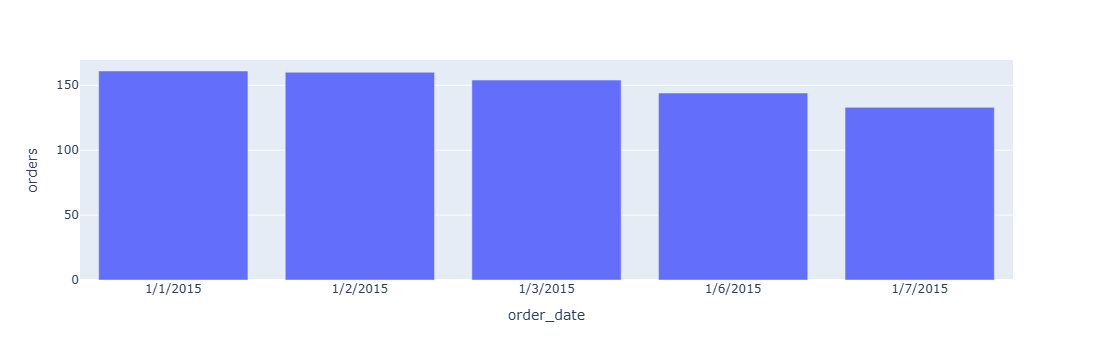

In [58]:
px.bar(top5_dates,x='order_date',y='orders')

In [59]:
pizza_size=pizza_df.groupby('min_pizza_size').agg({'total_qty':'sum'}).reset_index()

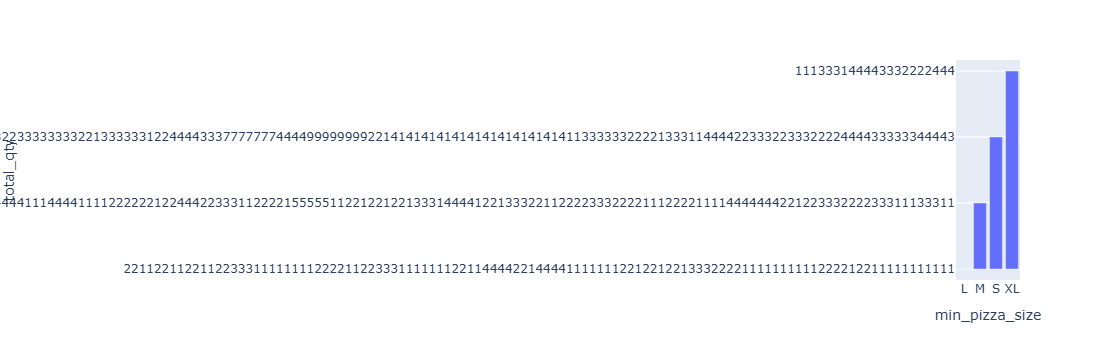

In [60]:
px.bar(pizza_size,x='min_pizza_size',y='total_qty')

In [61]:
pizza_df['full_date']=pizza_df['order_date']+' '+pizza_df['order_time']

In [62]:
pizza_df['full_date']=pd.to_datetime(pizza_df['full_date'],format='%m/%d/%Y %H:%M:%S')

In [63]:
hour_orders=pizza_df.groupby(pizza_df['full_date'].dt.hour).agg(
    {'order_id':'nunique'}).reset_index()

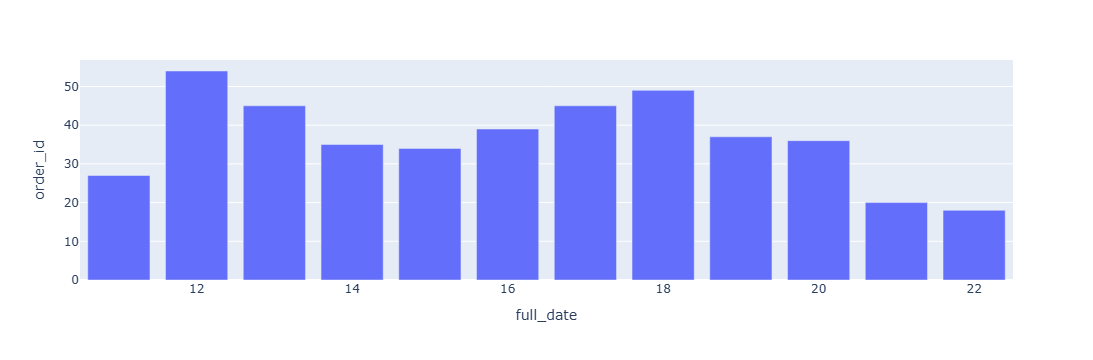

In [64]:
px.bar(hour_orders,x='full_date',y='order_id')

In [65]:
hour_orders

,full_date,order_id
0,11,27
1,12,54
2,13,45
3,14,35
4,15,34
5,16,39
6,17,45
7,18,49
8,19,37
9,20,36


In [66]:
pizza_df.columns

Index(['order_id', 'total_price', 'unique_pizza_count', 'total_qty',
       'order_date', 'unit_price', 'min_pizza_size', 'max_pizza_size',
       'unique_category_count', 'order_details_id', 'pizza_id', 'quantity',
       'order_time', 'pizza_size', 'pizza_category', 'pizza_ingredients',
       'pizza_name', 'Qty', 'ingredients', 'full_date'],
      dtype='object')

In [67]:
pizza_df['total_price']=pizza_df['total_price'].astype(float)
pizza_df['total_qty']=pizza_df['total_qty'].astype(float)
pizza_df['order_id']=pizza_df['order_id'].astype(float)

In [68]:
Pizza_table=pizza_df.groupby(
    'pizza_category').agg({
    'total_price':'mean','total_qty':'mean','order_id':'nunique'})

In [69]:
Pizza_table

,total_price,total_qty,order_id
pizza_category,,,
Chicken,60.631027,3.611607,175
Classic,57.624590,3.642623,226
Supreme,59.916109,3.594142,187
Veggie,58.992672,3.564655,183


In [70]:
for col  in Pizza_table.columns:
    if Pizza_table[col].dtypes!='object':
        Pizza_table[col]=Pizza_table[col].apply(lambda x:round(x))

In [71]:
Pizza_table

,total_price,total_qty,order_id
pizza_category,,,
Chicken,61,4,175
Classic,58,4,226
Supreme,60,4,187
Veggie,59,4,183


In [72]:
pizza_df['full_date'].dt.day.unique()

array([1, 2, 3, 4, 5, 6, 7, 8], dtype=int32)

In [73]:
pizza_df['total_sale']=pizza_df['total_qty']*pizza_df['total_price']

In [74]:
day_sale=pizza_df.groupby(pizza_df['full_date'].dt.date).agg(
    {'total_sale':'sum'}).reset_index()

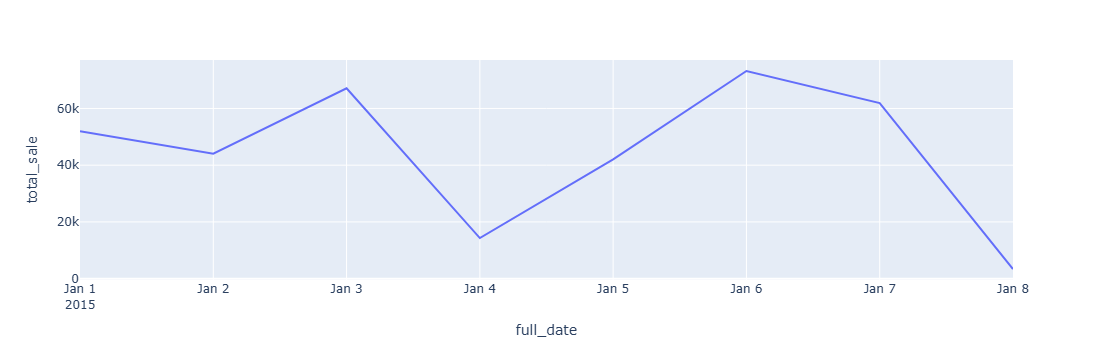

In [75]:
px.line(day_sale,x='full_date',y='total_sale')

In [1]:
pwd

'C:\\Users\\Lenovo\\OneDrive\\Desktop\\Pizza Store Performance'